## Basic substructures

...SMARTS to SMILES similar as regex to text.

We will try to search for a simple pattern ethanol in propanol, toluene and citric acid.

In [1]:
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import csv
from rdkit import RDLogger
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG
import itertools
import gzip
import pandas as pd

In [2]:
# SMARTS-based chemical substructures are instantiated much like the standard SMILES-based mol instances:
ethanol_pattern = Chem.MolFromSmarts('CCO')

# Pattern in propanol?
propanol = Chem.MolFromSmiles('CCCO') # a direct superstructure of ethanol
propanol.HasSubstructMatch(ethanol_pattern)

True

In [3]:
# Pattern in toluene? (without the CCO substructure)
toluene = Chem.MolFromSmiles('Cc1ccccc1')
toluene.HasSubstructMatch(ethanol_pattern)

False

In [4]:
# Pattern in citric acid?
# including the CCO in CC(O)OH group of carboxylic acids
citric_acid = Chem.MolFromSmiles('OC(=O)CC(O)(C(=O)O)CC(=O)O')
citric_acid.HasSubstructMatch(ethanol_pattern)

True

In [5]:
# The RDKit functionality also goes well beyond the basic binary does/doesn't match.
# Function GetSubstructMatch will get indices of all matching atoms and bonds
# within the target molecule
import itertools # for getting combinations without having to write additional function
compound = Chem.MolFromSmiles("OCCCCCCCCCCO")
hit_atoms = compound.GetSubstructMatch(ethanol_pattern) # indices of matching atoms
hit_bonds = [compound.GetBondBetweenAtoms(i, j).GetIdx()
             for i, j in itertools.combinations(hit_atoms, 2)
             if compound.GetBondBetweenAtoms(i, j)]
hit_atoms, hit_bonds

((2, 1, 0), [1, 0])

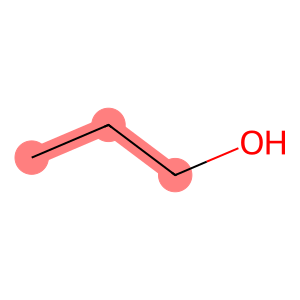

In [6]:
# Show the pattern
d = rdMolDraw2D.MolDraw2DSVG(300,300)
rdMolDraw2D.PrepareAndDrawMolecule(d, propanol, highlightAtoms=hit_atoms, highlightBonds=hit_bonds)
d.FinishDrawing()
display(SVG(d.GetDrawingText()))

Let's write the visualization into a method:

In [7]:
def visualize_match(structure, pattern):
    # GetSubstructMatches grabs all hits, GetSubstructMatch the first one it finds
    hits = structure.GetSubstructMatches(pattern)
    hit_atoms = set()
    hit_bonds = set()
    for hit in hits:
        hit_atoms.update(hit)
        hit_bonds.update([structure.GetBondBetweenAtoms(i, j).GetIdx()
                          for i, j in itertools.combinations(hit_atoms, 2)
                          if structure.GetBondBetweenAtoms(i, j)])
    d = rdMolDraw2D.MolDraw2DSVG(300,300)
    rdMolDraw2D.PrepareAndDrawMolecule(d, structure, highlightAtoms=hit_atoms, highlightBonds=hit_bonds)
    d.FinishDrawing()
    #return d.GetDrawingText()
    display(SVG(d.GetDrawingText()))

And now test it on citric acid and ethanol patterns:

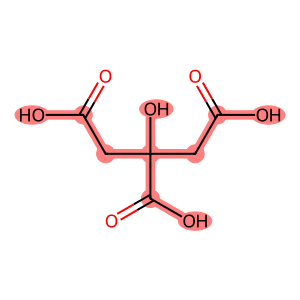

In [9]:
visualize_match(citric_acid, ethanol_pattern)

Test on citric acid and COOH groups:

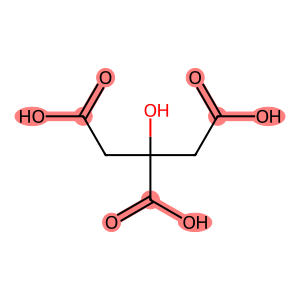

In [10]:
cooh_pattern = Chem.MolFromSmarts('C(=O)[O;h1]')
# means C (double bond to O on a sidechain) O with one implicit hydrogen
visualize_match(citric_acid, cooh_pattern)

Looks about right.

How many structures with COOH group do we have in MTOR and Drugbank datasets actually?

In [20]:
df = pd.read_csv("../my_data/structures_smiles.csv")
df["mol"] = df["Canonical_SMILES"].apply(Chem.MolFromSmiles)
df

,Canonical_SMILES,drugbank_id,ChEMBL ID,zincid,mol
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,1.0,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,2.0,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,3.0,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,4.0,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,5.0,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...
...,...,...,...,...,...
18891,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,NaN,NaN,ZINCrn00001eRwYj,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...
18892,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,NaN,NaN,ZINCsN000009Nrlo,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...
18893,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,NaN,NaN,ZINCtB00000oxE6f,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...
18894,CC(C)(CF)C(=O)N1CC2(CC[C@H](CNC(=O)c3ccnc(Cl)c...,NaN,NaN,ZINCrt0000052OFP,<rdkit.Chem.rdchem.Mol object at 0x0000015F29C...


In [ ]:
counts={'DrugBank':{"count":0,"sub":0},'mtor':{"count":0,"sub":0},"rock":{"count":0,"sub":0}}
for mol in joint_df.iterrows():
    counts[mol[1]["source"]]["count"] += 1
    if mol[1]["mol"].HasSubstructMatch(cooh_pattern):
        counts[mol[1]["source"]]["sub"]+=1
counts

In [24]:
cooh_pattern = Chem.MolFromSmarts("C(=O)[O;H1]")

sources = {
    "DrugBank": df[df["drugbank_id"].notna()],
    "ChEMBL": df[df["ChEMBL ID"].notna()],
    "ZINC": df[df["zincid"].notna()],
}

cooh_counts = {}
for name, subset in sources.items():
    valid = subset[subset["mol"].notna()].copy()
    valid["has_cooh"] = valid["mol"].apply(lambda m: m.HasSubstructMatch(cooh_pattern))
    total = len(valid)
    with_cooh = int(valid["has_cooh"].sum())
    cooh_counts[name] = {
        "total_structures": total,
        "with_cooh": with_cooh,
        "with_cooh_percent": round(with_cooh / total * 100, 2) if total else 0,
    }

pd.DataFrame(cooh_counts).T


,total_structures,with_cooh,with_cooh_percent
DrugBank,7120.0,1683.0,23.64
ChEMBL,4596.0,24.0,0.52
ZINC,7180.0,110.0,1.53


Apparently COOH group is more common in Drugbank.

DrugBank


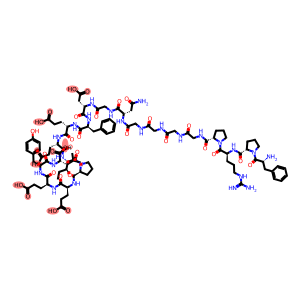

ChEMBL


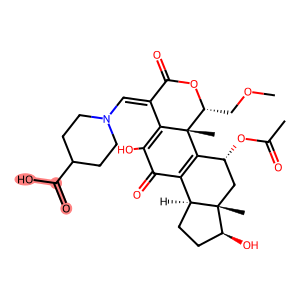

ZINC


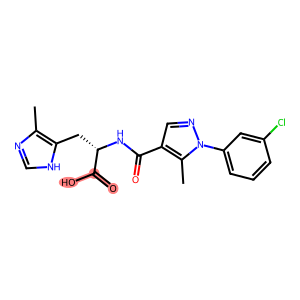

In [22]:
for name, subset in sources.items():
    example = subset[subset["mol"].notna() & subset["mol"].apply(lambda m: m.HasSubstructMatch(cooh_pattern))].iloc[0]
    print(name)
    visualize_match(example["mol"], cooh_pattern)


Wow thats cool...

## PAINS

These are structural patterns that are known to interfere with the mechanism of assays used to screen for substances with a desired biological activity. These structures are likely to come up as false positivies in assays, and might become a trap that consumes time and resources of those unfamiliar with those factors.

In [26]:
from itertools import chain
# load PAINS structures in SMARTS format from two files in data
pains = []
with open('../data/pains/p_l15.txt', 'r') as f, open('../data/pains/p_m150.txt', 'r') as p:
    for line in chain(f, p):
        pattern, text = line.strip().split('\t') # split by tab
        pains.append([Chem.MolFromSmarts(pattern),
                      text.lstrip("<regId=\"").rstrip("\">")]) # remove the xml tags
pains, len(pains)

([[<rdkit.Chem.rdchem.Mol at 0x15f3be42a40>, 'anil_di_alk_F(14)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be42260>, 'hzone_anil(14)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be42c00>, 'het_5_pyrazole_OH(14)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be43060>, 'het_thio_666_A(13)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be430d0>, 'styrene_A(13)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be43220>, 'ne_rhod_C(13)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be43300>, 'hp_amino_CN_A(13)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be43140>, 'cyano_imine_C(12)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be431b0>, 'thio_urea_A(12)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be43290>, 'thiophene_amino_B(12)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be43370>, 'keto_keto_beta_B(12)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be43450>, 'keto_phenone_A(11)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be433e0>, 'cyano_pyridone_C(11)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be434c0>, 'thiaz_ene_C(11)'],
  [<rdkit.Chem.rdchem.Mol at 0x15f3be43530>, 'hzone_thiophene

So, we have parsed over 400 known PAINS, in a list of (pattern, patternname) pairs. Let's scan our MTOR set, you process yours... substruct search is expensive, so it might take a while :)

In [41]:
chembl_subset = df[df["ChEMBL ID"].notna() & df["mol"].notna()].copy()

chembl_pains_hits = []
chembl_pains_details = []

for _, row in chembl_subset.iterrows():
    mol = row["mol"]
    matched_pains = [name for pattern, name in pains if pattern is not None and mol.HasSubstructMatch(pattern)]
    if matched_pains:
        chembl_pains_hits.append(mol)
        chembl_pains_details.append({
            "ChEMBL ID": row["ChEMBL ID"],
            "Canonical_SMILES": row["Canonical_SMILES"],
            "mol": mol,
            "matched_pains": matched_pains,
        })

print(f"ChEMBL molecules scanned: {len(chembl_subset)}")
print(f"ChEMBL molecules with at least one PAINS match: {len(chembl_pains_hits)}")

ChEMBL molecules scanned: 4596
ChEMBL molecules with at least one PAINS match: 1


In [42]:
chembl_pains_details_df = pd.DataFrame(chembl_pains_details)
chembl_pains_details_df.head()


,ChEMBL ID,Canonical_SMILES,mol,matched_pains
0,CHEMBL405258,COC[C@H]1OC(=O)/C(=C/N(C)CCCN2CCN(c3ccc(OC)cc3...,<rdkit.Chem.rdchem.Mol object at 0x0000015F29B...,[anil_di_alk_C(246)]


So there is one molecule with PAINS pattern. How does it look like?

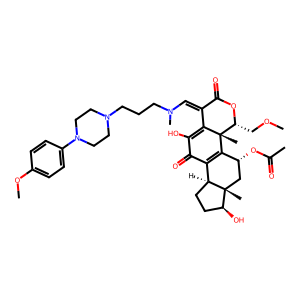

In [44]:
Draw.MolToImage(chembl_pains_details_df.iloc[0]["mol"])


Looks like something large with a steroid-like core. What PAINS did it trigger?

In [45]:
hit_row = chembl_pains_details_df.iloc[0]
hit_row[["ChEMBL ID", "Canonical_SMILES", "matched_pains"]]

ChEMBL ID                                                CHEMBL405258
Canonical_SMILES    COC[C@H]1OC(=O)/C(=C/N(C)CCCN2CCN(c3ccc(OC)cc3...
matched_pains                                    [anil_di_alk_C(246)]
Name: 0, dtype: object

Matched PAINS pattern(s):
- anil_di_alk_C(246)

anil_di_alk_C(246)


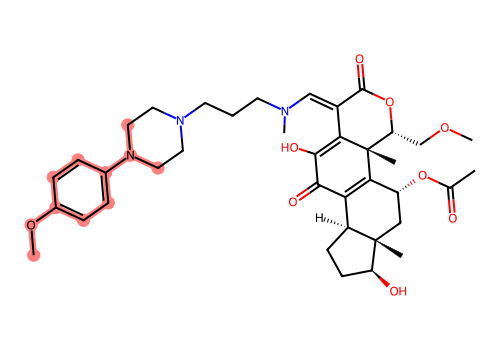

In [46]:
target_mol = hit_row["mol"]
target_names = hit_row["matched_pains"]

matched_patterns = [(pattern, name) for pattern, name in pains if name in target_names]

print("Matched PAINS pattern(s):")
for _, name in matched_patterns:
    print("-", name)

for pattern, name in matched_patterns:
    matches = target_mol.GetSubstructMatches(pattern)
    hit_atoms = set()
    hit_bonds = set()

    for match in matches:
        hit_atoms.update(match)
        for i, j in itertools.combinations(match, 2):
            bond = target_mol.GetBondBetweenAtoms(i, j)
            if bond is not None:
                hit_bonds.add(bond.GetIdx())

    print(f"\n{name}")
    d = rdMolDraw2D.MolDraw2DSVG(500, 350)
    rdMolDraw2D.PrepareAndDrawMolecule(
        d,
        target_mol,
        highlightAtoms=list(hit_atoms),
        highlightBonds=list(hit_bonds),
    )
    d.FinishDrawing()
    display(SVG(d.GetDrawingText()))


Here we can see the PAINS pattern highlighted in the molecule structure. We can see thesubstructure that triggered the PAINS warning.